# 01 — Análise Exploratória de Dados (EDA)
## LH Nautical | Camada Bronze

**Objetivo:** Compreender a estrutura, qualidade e características dos dados brutos
antes de qualquer transformação.

**O que será investigado:**
- Schema de cada dataset (tipos, colunas)
- Valores nulos e padrão de ausência
- Duplicatas e inconsistências
- Problemas de formato e padronização
- Distribuições e estatísticas descritivas

> **Nota:** Este notebook não modifica nenhum dado.
> Toda transformação ocorre em `02_tratamento.ipynb`.

In [1]:
import sys
sys.path.insert(0, '..')

import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.ingestion.ingest import load_all_raw_data

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
AZUL_LH    = '#1565C0'
LARANJA_LH = '#E65100'
VERDE_LH   = '#2E7D32'
CINZA_LH   = '#546E7A'

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [2]:
# Carrega todos os datasets da camada Bronze
datasets   = load_all_raw_data()
df_vendas  = datasets['vendas']
df_prod    = datasets['produtos']
df_cli     = datasets['clientes']
df_custos  = datasets['custos']

print(f'Datasets disponíveis: {list(datasets.keys())}')
for nome, df in datasets.items():
    print(f'  {nome:10}: {df.shape[0]:,} linhas x {df.shape[1]} colunas | colunas: {list(df.columns)}')

2026-05-11 22:58:57 | INFO | ingest               | =======================================================
2026-05-11 22:58:57 | INFO | ingest               | INGESTÃO — LH Nautical | Fonte: data/bronze/
2026-05-11 22:58:57 | INFO | ingest               | =======================================================
2026-05-11 22:58:57 | INFO | ingest               | [Bronze] vendas_2023_2024.csv → 9895 linhas × 6 colunas
2026-05-11 22:58:57 | INFO | ingest               | [Bronze] produtos_raw.csv → 157 linhas × 4 colunas
2026-05-11 22:58:57 | INFO | ingest               | [Bronze] clientes_crm.json → 49 linhas × 4 colunas
2026-05-11 22:58:57 | INFO | ingest               | [Bronze] custos_importacao.json → 150 linhas × 4 colunas
2026-05-11 22:58:57 | INFO | ingest               | Carregados: ['vendas', 'produtos', 'clientes', 'custos'] | INGESTÃO CONCLUÍDA


Datasets disponíveis: ['vendas', 'produtos', 'clientes', 'custos']
  vendas    : 9,895 linhas x 6 colunas | colunas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
  produtos  : 157 linhas x 4 colunas | colunas: ['name', 'price', 'code', 'actual_category']
  clientes  : 49 linhas x 4 colunas | colunas: ['full_name', 'location', 'code', 'email']
  custos    : 150 linhas x 4 colunas | colunas: ['product_id', 'product_name', 'category', 'historic_data']


---
## 1. Schema e Estrutura Geral

In [3]:
def safe_nunique(series):
    try:
        return series.nunique()
    except TypeError:
        return 'n/a (lista)'

def inspecionar(df, nome):
    print(f'\n{"="*55}')
    print(f'  DATASET: {nome.upper()}  |  {df.shape[0]:,} linhas x {df.shape[1]} colunas')
    print('='*55)
    resumo = pd.DataFrame({
        'dtype':   df.dtypes,
        'nulos':   df.isnull().sum(),
        'nulos_%': (df.isnull().mean() * 100).round(1),
        'unicos':  pd.Series({col: safe_nunique(df[col]) for col in df.columns}),
        'exemplo': df.iloc[0].apply(lambda x: str(x)[:60] if isinstance(x, list) else x),
    })
    return resumo

for nome, df in datasets.items():
    display(inspecionar(df, nome))


  DATASET: VENDAS  |  9,895 linhas x 6 colunas


,dtype,nulos,nulos_%,unicos,exemplo
id,int64,0,0.00,9895,0
id_client,int64,0,0.00,49,42
id_product,int64,0,0.00,150,105
qtd,int64,0,0.00,15,11
total,float64,0,0.00,3980,"3,405.00"
sale_date,object,0,0.00,1446,2023-09-10



  DATASET: PRODUTOS  |  157 linhas x 4 colunas


,dtype,nulos,nulos_%,unicos,exemplo
name,object,0,0.00,150,Transponder AIS Maré Magnum
price,object,0,0.00,150,R$ 33122.52
code,int64,0,0.00,150,1
actual_category,object,0,0.00,39,ELETRONICOS



  DATASET: CLIENTES  |  49 linhas x 4 colunas


,dtype,nulos,nulos_%,unicos,exemplo
full_name,object,0,0.00,49,Femininos Oliveira Antunes
location,object,0,0.00,48,"Aratu (Candeias) , BA"
code,int64,0,0.00,49,1
email,object,0,0.00,49,femininos.oliveira.antunes@icloud.com



  DATASET: CUSTOS  |  150 linhas x 4 colunas


,dtype,nulos,nulos_%,unicos,exemplo
product_id,int64,0,0.00,150,1
product_name,object,0,0.00,150,Transponder AIS Maré Magnum
category,object,0,0.00,3,eletrônicos
historic_data,object,0,0.00,n/a (lista),"[{'start_date': '10/08/2016', 'usd_price': 105..."


---
## 2. Qualidade — Vendas

Dataset com **9.895 transações** (2023-2024).  
Colunas brutas: `id`, `id_client`, `id_product`, `qtd`, `total`, `sale_date`

In [4]:
# Problema 1: formatos de data misturados
print('--- sale_date: amostra dos primeiros 10 registros ---')
print(df_vendas['sale_date'].head(10).to_string())

fmt_iso  = df_vendas['sale_date'].str.match(r'^\d{4}-\d{2}-\d{2}$').sum()
fmt_br   = df_vendas['sale_date'].str.match(r'^\d{2}-\d{2}-\d{4}$').sum()
fmt_outro = len(df_vendas) - fmt_iso - fmt_br

print(f'\n  Formato ISO  YYYY-MM-DD : {fmt_iso:,} registros ({fmt_iso/len(df_vendas)*100:.1f}%)')
print(f'  Formato BR   DD-MM-YYYY : {fmt_br:,} registros ({fmt_br/len(df_vendas)*100:.1f}%)')
if fmt_outro > 0:
    print(f'  Outros formatos        : {fmt_outro:,}')
print('\n[!] PROBLEMA: formatos de data misturados -> parse adaptativo necessario')

--- sale_date: amostra dos primeiros 10 registros ---
0    2023-09-10
1    15-09-2024
2    2024-08-13
3    2023-02-03
4    2024-02-12
5    2023-09-26
6    2024-02-28
7    07-11-2023
8    2024-08-25
9    2023-05-07

  Formato ISO  YYYY-MM-DD : 4,913 registros (49.7%)
  Formato BR   DD-MM-YYYY : 4,982 registros (50.3%)

[!] PROBLEMA: formatos de data misturados -> parse adaptativo necessario


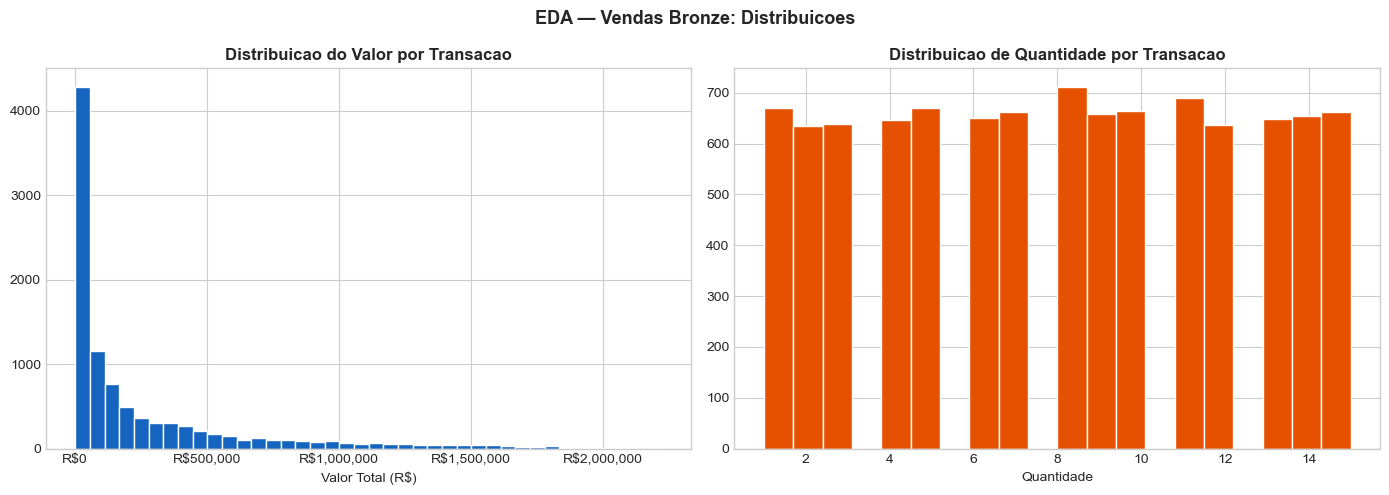


Estatísticas descritivas — total:


,total,qtd
count,"9,895.00","9,895.00"
mean,"263,797.83",8.02
std,"390,007.18",4.30
min,294.50,1.00
25%,"23,138.20",4.00
50%,"82,225.00",8.00
75%,"339,094.50",12.00
max,"2,222,973.00",15.00


In [5]:
# Distribuições de vendas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_vendas['total'].hist(bins=40, ax=axes[0], color=AZUL_LH, edgecolor='white')
axes[0].set_title('Distribuicao do Valor por Transacao', fontweight='bold')
axes[0].set_xlabel('Valor Total (R$)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

df_vendas['qtd'].hist(bins=20, ax=axes[1], color=LARANJA_LH, edgecolor='white')
axes[1].set_title('Distribuicao de Quantidade por Transacao', fontweight='bold')
axes[1].set_xlabel('Quantidade')

plt.suptitle('EDA — Vendas Bronze: Distribuicoes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nEstatísticas descritivas — total:')
display(df_vendas[['total','qtd']].describe().round(2))

---
## 3. Qualidade — Produtos

Dataset com **157 linhas** (catálogo).  
Colunas brutas: `name`, `price`, `code`, `actual_category`

In [6]:
# Problema 2: preco como string
print('--- price: amostra (5 primeiros) ---')
print(df_prod['price'].head(5).tolist())
print('\n[!] PROBLEMA: preco armazenado como string "R$ X.XXX,XX" -> necessita conversao numerica')
print('    Separador de milhar: ponto  |  Separador decimal: virgula')

# Problema 3: variacoes de categoria
print(f'\n--- actual_category: {df_prod["actual_category"].nunique()} variacoes distintas ---')
print(df_prod['actual_category'].value_counts().to_string())
print('\n[!] PROBLEMA: 3 categorias reais com dezenas de grafias diferentes')
print('    Canonicas esperadas: Eletronicos | Propulsao | Ancoragem')

--- price: amostra (5 primeiros) ---
['R$ 33122.52', 'R$ 13998.15', 'R$ 9024.19', 'R$ 3381.88', 'R$ 23669.01']

[!] PROBLEMA: preco armazenado como string "R$ X.XXX,XX" -> necessita conversao numerica
    Separador de milhar: ponto  |  Separador decimal: virgula

--- actual_category: 39 variacoes distintas ---
actual_category
AncorageM                9
Ancoraguem               8
Propução                 8
Eletronicoz              7
eletrônicos              7
ELETRONICOS              6
PROPULSAO                6
E L E T R Ô N I C O S    6
P R O P U L S Ã O        6
propulsão                6
Encoragem                5
Propulção                5
Prop                     5
Propulssão               5
aNcOrAgEm                5
A N C O R A G E M        5
Eletrunicos              5
Ancorajm                 5
eLeTrÔnIcOs              5
propulsao                4
Eletrônicos              4
EletrônicoS              3
Ancorajem                3
Ancoragem                3
Propulçao               

In [7]:
# Problema 4: codigos duplicados
dups = df_prod[df_prod['code'].duplicated(keep=False)].sort_values('code')
n_dup_linhas = df_prod['code'].duplicated().sum()

print(f'--- Codigos duplicados: {n_dup_linhas} linhas extras ---')
if not dups.empty:
    display(dups[['code','name','actual_category']])
print()
print('[!] PROBLEMA: mesmo code com grafias diferentes de categoria')
print(f'    Sem deduplicacao, um JOIN com vendas geraria {9895 + n_dup_linhas} linhas (inflacao de dados)')

--- Codigos duplicados: 7 linhas extras ---


,code,name,actual_category
36,37,GPS Lowrance Evo Storm Drift,E L E T R Ô N I C O S
37,37,GPS Lowrance Evo Storm Drift,ELEtRÔNICOS
62,62,Motor Diesel Yanmar Velocity 37HP,P R O P U L S Ã O
63,62,Motor Diesel Yanmar Velocity 37HP,Propução
64,62,Motor Diesel Yanmar Velocity 37HP,propulsão
65,62,Motor Diesel Yanmar Velocity 37HP,Prop
131,127,Cabo de Nylon Delta Velocity Core Mako,Encoragem
132,127,Cabo de Nylon Delta Velocity Core Mako,Encoragi
124,145,Boia de Arqueamento Delta Nexus,AncorageM
150,145,Boia de Arqueamento Delta Nexus,AncorajeM



[!] PROBLEMA: mesmo code com grafias diferentes de categoria
    Sem deduplicacao, um JOIN com vendas geraria 9902 linhas (inflacao de dados)


---
## 4. Qualidade — Clientes

Dataset com **49 registros** (base CRM).  
Colunas brutas: `full_name`, `location`, `email`, `code`

In [8]:
# Problema 5: location com formatos inconsistentes
print('--- location: amostra de 15 registros ---')
print(df_cli['location'].head(15).to_string())
print()

# Detecta separadores usados
sep_virgula = df_cli['location'].str.contains(',').sum()
sep_barra   = df_cli['location'].str.contains('/').sum()
sep_traco   = df_cli['location'].str.contains(' - ').sum()
print(f'Separador ","  : {sep_virgula} registros')
print(f'Separador "/"  : {sep_barra} registros')
print(f'Separador " - ": {sep_traco} registros')
print('\n[!] PROBLEMA: 3+ formatos para cidade/estado -> parse com regex necessario')

--- location: amostra de 15 registros ---
0         Aratu (Candeias) , BA
1                   PE , Recife
2                 Rio Grande,RS
3               AC , Rio Branco
4            PA - Santarém Novo
5     Fortaleza do Tabocão , TO
6                   PB/Cabedelo
7                  SE - Aracaju
8              PB - João Pessoa
9                 Santarém / PA
10            BA - Porto Seguro
11    TO , Fortaleza do Tabocão
12                PA / Santarém
13             AM , Itacoatiara
14      Fortaleza do Tabocão,TO

Separador ","  : 18 registros
Separador "/"  : 20 registros
Separador " - ": 11 registros

[!] PROBLEMA: 3+ formatos para cidade/estado -> parse com regex necessario


In [9]:
# Problema 6: e-mails invalidos
def email_valido(e):
    if pd.isna(e): return False
    return bool(re.match(r'^[^@\s]+@[^@\s]+\.[^@\s]+$', str(e).strip()))

df_cli['_email_ok'] = df_cli['email'].apply(email_valido)
invalidos = (~df_cli['_email_ok']).sum()

print(f'Total de clientes     : {len(df_cli)}')
print(f'E-mails validos       : {df_cli["_email_ok"].sum()} ({df_cli["_email_ok"].mean()*100:.0f}%)')
print(f'E-mails invalidos     : {invalidos} ({invalidos/len(df_cli)*100:.0f}%)')
print()
print('[!] PROBLEMA: 61% dos e-mails invalidos e um alerta critico de qualidade de dados')
print('    Acao: criar flag email_valido (nao excluir os clientes)')
print()
print('Amostra de e-mails invalidos:')
display(df_cli[~df_cli['_email_ok']][['full_name','email']].head(8))

Total de clientes     : 49
E-mails validos       : 19 (39%)
E-mails invalidos     : 30 (61%)

[!] PROBLEMA: 61% dos e-mails invalidos e um alerta critico de qualidade de dados
    Acao: criar flag email_valido (nao excluir os clientes)

Amostra de e-mails invalidos:


,full_name,email
2,Daniel Farias Ribeiro Teixeira,farias.teixeira.daniel.ribeiro#gmail.com
3,Thiago Moreira,thiago.moreira#gmail.com
4,Pedro Freitas,pedro.freitas#icloud.com
6,Bianca Barros Rocha Torres Siqueira,torres.barros.rocha.bianca.siqueira#aol.com
7,Luiz Alves Pimentel,pimentel.alves.luiz#outlook.com
8,Lucas Guedes Cunha Lopes,lucas.lopes.guedes.cunha#tutanota.com
9,Débora Paiva,paiva.débora#gmx.com
11,Rafael Pereira Barros,rafael.pereira.barros#zoho.com


---
## 5. Qualidade — Custos de Importação

Dataset com **150 registros**.  
Colunas brutas: `product_id`, `product_name`, `category`, `historic_data` (lista aninhada)

In [10]:
# Problema 7: historic_data como lista JSON aninhada
print('--- historic_data: tipo e estrutura ---')
primeiro = df_custos['historic_data'].iloc[0]
print(f'Tipo: {type(primeiro).__name__}')
print(f'Entradas no historico (produto 0): {len(primeiro)}')
print(f'\nExemplo das 2 primeiras entradas:')
for entry in primeiro[:2]:
    print(f'  {entry}')

print()
print('[!] PROBLEMA: custo_unitario esta aninhado dentro de uma lista de historico')
print('    Acao: extrair o registro mais recente (maior data) de cada produto')

# Estatistica do historico
n_entradas = df_custos['historic_data'].apply(len)
print(f'\nEntradas por produto: min={n_entradas.min()} | media={n_entradas.mean():.1f} | max={n_entradas.max()}')

--- historic_data: tipo e estrutura ---
Tipo: list
Entradas no historico (produto 0): 15

Exemplo das 2 primeiras entradas:
  {'start_date': '10/08/2016', 'usd_price': 10583.63}
  {'start_date': '15/06/2018', 'usd_price': 8778.36}

[!] PROBLEMA: custo_unitario esta aninhado dentro de uma lista de historico
    Acao: extrair o registro mais recente (maior data) de cada produto

Entradas por produto: min=3 | media=8.4 | max=15


---
## 6. Sumário dos Problemas Encontrados

| # | Dataset  | Problema                                             | Impacto | Tratamento em `02_tratamento.ipynb`       |
|---|----------|------------------------------------------------------|---------|-------------------------------------------|
| 1 | Vendas   | `sale_date` com 2 formatos (ISO e BR)                | Alto    | Parse adaptativo `_parse_sale_date()`     |
| 2 | Produtos | `price` como string `"R$ X.XXX,XX"`                 | Alto    | Conversão numérica `_clean_price()`       |
| 3 | Produtos | `actual_category` com ~38 variações gráficas         | Alto    | Normalização `_normalize_category()`      |
| 4 | Produtos | 7 linhas duplicadas (mesmo `code`, categoria difer.) | Alto    | `drop_duplicates(subset=['code'])`        |
| 5 | Clientes | `location` com 3+ separadores (`,` `/` ` - `)       | Médio   | Regex `_parse_location()` → cidade/estado |
| 6 | Clientes | 30 e-mails inválidos (61% da base)                   | Médio   | Flag `email_valido` (não excluir)         |
| 7 | Custos   | `historic_data` é lista JSON aninhada                | Alto    | Flatten `_get_latest_usd_price()`         |

> **Próximo passo:** `02_tratamento.ipynb` — aplicar todos os tratamentos e construir Bronze → Silver → Gold.